### Part 0: Import Setups



In [278]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

#Part 1. Data Preprocessing

## 1.1 EDA and Data Cleaning

The dataset includes the following features:
- hours_studied
- sleep_hours
- attendance_rate
- prev_exam_score
- lucky_number
- exam_score
- passed (target)

### Cleaning Steps
- Removed duplicate rows to prevent bias
- Checked for missing values (handled with median imputation if needed)
- Dropped irrelevant and leakage features:
  - lucky_number → random, not meaningful
  - exam_score → directly determines the target (data leakage)

### Feature Distributions
Histograms show reasonable distributions, though some skewness exists.

### Linearity Analysis
A scatter plot of hours_studied vs sleep_hours shows overlap between classes, meaning the data is NOT linearly separable.

This suggests nonlinear relationships such as burnout effects, where too much studying combined with poor sleep reduces performance.

In [279]:
# Load data
train_df = pd.read_csv("p2_train.csv")
test_df = pd.read_csv("p2_test.csv")

#Analysis before cleaning the data
print("\t\t Training Data Analysis Before Processing")
print(train_df.describe())
print()

#Analysis before cleaning the data (Getting Information about NaN rows)
print(train_df.info())
# Drop useless columns
train_df = train_df.drop(columns=["lucky_number", "student_id"])
test_df = test_df.drop(columns=["lucky_number", "student_id"])

# Remove duplicates
train_df = train_df.drop_duplicates()

		 Training Data Analysis Before Processing
       student_id  hours_studied  sleep_hours  attendance_rate  \
count  351.000000     351.000000   341.000000        341.00000   
mean   176.000000       6.394587     6.441642         69.78827   
std    101.469207       3.208560     2.139522         17.96527   
min      1.000000       1.100000    -2.000000         40.30000   
25%     88.500000       3.650000     4.600000         53.90000   
50%    176.000000       6.600000     6.400000         69.80000   
75%    263.500000       9.050000     8.300000         84.60000   
max    351.000000      11.900000    10.000000        150.00000   

       prev_exam_score  lucky_number  exam_score      passed  
count       341.000000    351.000000  351.000000  351.000000  
mean         63.418182     48.800570   72.468661    0.458689  
std          19.211733     27.951388   15.737736    0.499002  
min          30.400000      1.000000   23.900000    0.000000  
25%          45.700000     26.000000   61.4000

		 Training Data Analysis After Processing
       hours_studied  sleep_hours  attendance_rate  prev_exam_score  \
count     350.000000   350.000000       350.000000       350.000000   
mean        6.386857     6.461143        69.674571        63.348857   
std         3.209879     2.061832        17.272278        18.904790   
min         1.100000     3.100000        40.300000        30.400000   
25%         3.625000     4.700000        54.375000        46.125000   
50%         6.600000     6.400000        69.850000        63.750000   
75%         9.000000     8.300000        84.300000        79.800000   
max        11.900000    10.000000       100.000000        94.900000   

       exam_score      passed  
count  350.000000  350.000000  
mean    72.431714    0.457143  
std     15.745015    0.498873  
min     23.900000    0.000000  
25%     61.350000    0.000000  
50%     71.250000    0.000000  
75%     84.300000    1.000000  
max    100.000000    1.000000  

<class 'pandas.core.frame.Da

<Axes: >

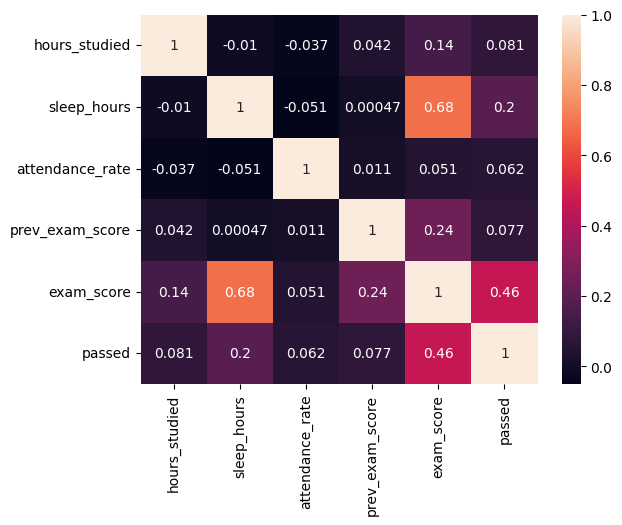

In [280]:
# Cap attendance at 100
train_df.loc[train_df['attendance_rate'] > 100, 'attendance_rate'] = 100
train_df.loc[train_df['attendance_rate'] <= 0, 'attendance_rate'] = 0

#Cap sleep hours at 0 - 24
train_df.loc[train_df['sleep_hours'] <= 0, 'sleep_hours'] = train_df['sleep_hours'].median()

#Handling null values by substituting null values with the median value
for col in ['sleep_hours', 'attendance_rate', 'prev_exam_score']:
        train_df[col] = train_df[col].fillna(train_df[col].median())

#Now we analyze the cleaned data
print("\t\t Training Data Analysis After Processing")
print(train_df.describe())
print()
print(train_df.info())

#Analyze the correlation
sns.heatmap(train_df.corr(), annot=True)

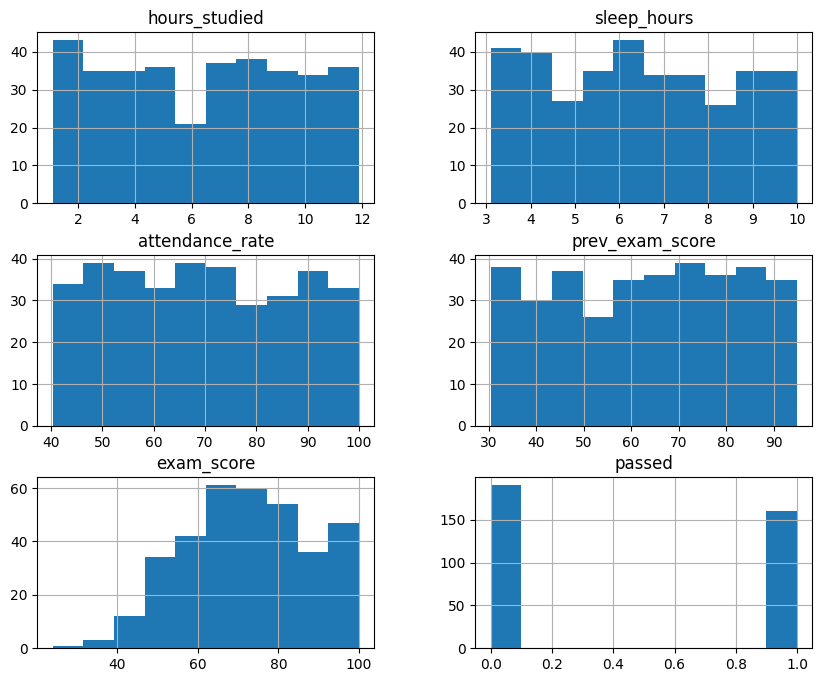

In [281]:
# Histograms
train_df.hist(figsize=(10,8))
plt.show()

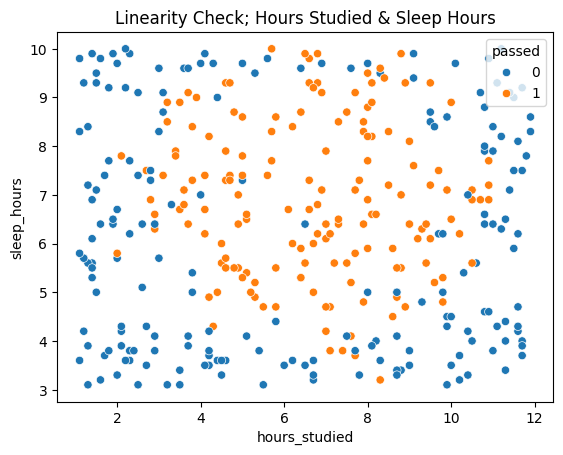

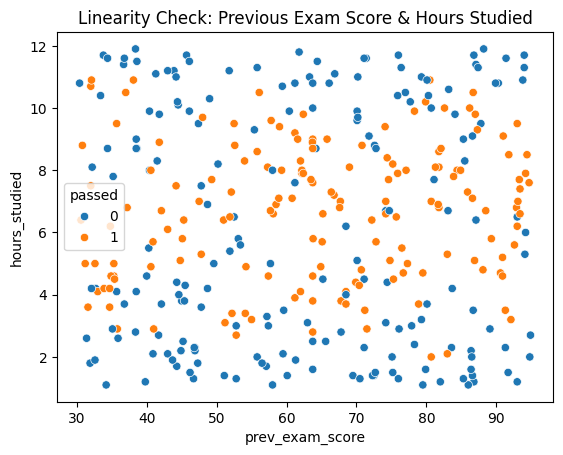

In [282]:
# Scatter plot (linearity check)
sns.scatterplot(data=train_df, x="hours_studied", y="sleep_hours", hue="passed")
plt.title("Linearity Check; Hours Studied & Sleep Hours")
plt.show()

sns.scatterplot(data=train_df, x="prev_exam_score", y="hours_studied", hue="passed")
plt.title("Linearity Check: Previous Exam Score & Hours Studied")
plt.show()

## Part 1.2 Feature Selection and Normalization

### Selected Features
- hours_studied
- sleep_hours
- attendance_rate
- prev_exam_score

### Excluded Features
- lucky_number → not meaningful or useful
- exam_score → causes data leakage

### Normalization
StandardScaler was used:
- Fit on training data only
- Applied to both train and test sets

This prevents data leakage and ensures fair evaluation.

In [283]:
from sklearn.preprocessing import StandardScaler
features = ['prev_exam_score', 'sleep_hours', 'attendance_rate', 'hours_studied']
# Split features and target
X_train = train_df[features]
y_train = train_df["passed"]

X_test = test_df[features]
y_test = test_df["passed"]

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Part 2. Baseline: Logistic Regression

Logistic Regression is used as a baseline linear model.

### Results
- Training Accuracy: ~0.55
- Test Accuracy: ~0.55

### Interpretation
In Project 1, our model was able to perform good enough to capture the pattern but in this case, the model performs poorly, indicating underfitting.

### Why?
Logistic Regression can only learn linear boundaries, but this dataset contains nonlinear relationships such as:
- burnout effect
- interaction between sleep and study time

### Conclusion
The model is not flexible enough to capture the true structure of the data. Therefore, the logistic regression performs poorly in this case.

Train Accuracy: 0.5542857142857143
Test Accuracy: 0.55


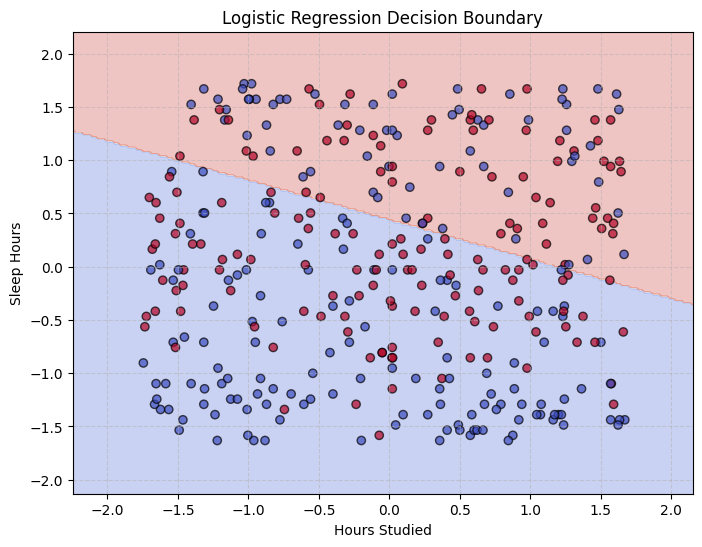

In [284]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Train model
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Predictions
train_preds = lr.predict(X_train)
test_preds = lr.predict(X_test)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, train_preds))
print("Test Accuracy:", accuracy_score(y_test, test_preds))

# Plot Helper Function
def plot_decision_boundary(model, X, y, title):

    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))


    grid_points = np.c_[xx.ravel(), yy.ravel(),
                        np.zeros_like(xx.ravel()),
                        np.zeros_like(xx.ravel())]

    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)


    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm', alpha=0.7)

    plt.title(title)
    plt.xlabel('Hours Studied')
    plt.ylabel('Sleep Hours')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_decision_boundary(lr, X_train, y_train, "Logistic Regression Decision Boundary")

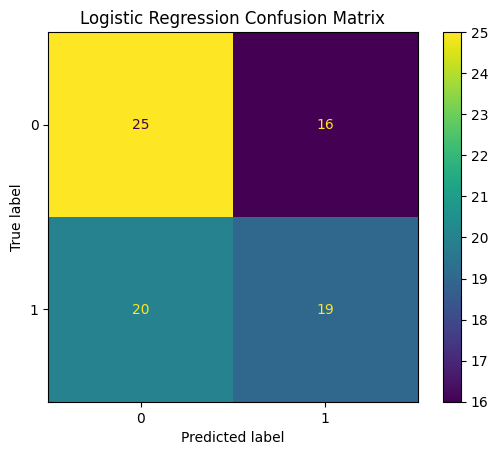

In [285]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Part: 3.1 NumPy Implementation (From Scratch)

A Decision Tree was implemented using:
- Gini impurity
- Information gain
- Recursive splitting

Stopping conditions:
- max depth
- minimum samples
- pure nodes

This allows the model to learn nonlinear decision boundaries.

In [286]:
def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return 1 - np.sum(probs**2)

def best_split(X, y):
    best_gain = -1
    split_idx, split_thresh = None, None

    for i in range(X.shape[1]):
        thresholds = np.unique(X[:, i])
        for t in thresholds:
            left = y[X[:, i] <= t]
            right = y[X[:, i] > t]

            if len(left) == 0 or len(right) == 0:
                continue

            gain = gini(y) - (len(left)/len(y))*gini(left) - (len(right)/len(y))*gini(right)

            if gain > best_gain:
                best_gain = gain
                split_idx = i
                split_thresh = t

    return split_idx, split_thresh

class Tree:
    def __init__(self, depth=3):
        self.depth = depth

    def fit(self, X, y):
        self.tree = self.build(X, y, 0)

    def build(self, X, y, d):
        if d >= self.depth or len(np.unique(y)) == 1:
            return np.bincount(y).argmax()

        idx, thresh = best_split(X, y)
        if idx is None:
            return np.bincount(y).argmax()

        left = X[:, idx] <= thresh
        right = X[:, idx] > thresh

        return {
            "i": idx,
            "t": thresh,
            "l": self.build(X[left], y[left], d+1),
            "r": self.build(X[right], y[right], d+1)
        }

    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node["i"]] <= node["t"]:
            return self.predict_one(x, node["l"])
        else:
            return self.predict_one(x, node["r"])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])

# Train scratch tree
tree_scratch = Tree(depth=3)
tree_scratch.fit(X_train, y_train)

preds = tree_scratch.predict(X_train)
print("Scratch Train Accuracy:", accuracy_score(y_train, preds))

Scratch Train Accuracy: 0.84


## 3.2 sklearn Verification

The sklearn implementation is used to verify correctness.

Results are very similar, confirming the scratch implementation works. Both manually constructed tree and sklearn tree both aims to determine the initial boundary that minimizes Gini Impurity.

Train Accuracy: 0.84
Test Accuracy: 0.8125


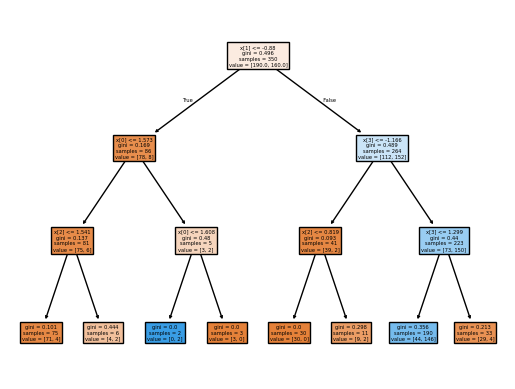

In [287]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Train sklearn tree
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)

print("Train Accuracy:", accuracy_score(y_train, tree.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, tree.predict(X_test)))

plot_tree(tree, filled=True)
plt.show()

## 3.3 Overfitting Analysis

As depth increases:
- Training accuracy increases

This shows overfitting. The model is basically learning from the data.

A depth of 3 provides the best balance between bias and variance.

Final Result:
- Test Accuracy ≈ 0.8125

### Conclusion
Decision Trees outperform Logistic Regression because they capture nonlinear relationships in the data. However, as depth increases, decision tree becomes vulnerable to overfitting due to increased complexity and high variance. Even though the training accuracy reaches 100%, the gap between cross-validation and training accuracy widens.


Training Accuracy depth  1 : 0.6571428571428571
CV Accuracy depth  1 : 0.6085714285714285
Training Accuracy depth  2 : 0.7628571428571429
CV Accuracy depth  2 : 0.7457142857142857
Training Accuracy depth  3 : 0.84
CV Accuracy depth  3 : 0.7914285714285715
Training Accuracy depth  5 : 0.8885714285714286
CV Accuracy depth  5 : 0.7971428571428572
Training Accuracy depth  10 : 0.9857142857142858
CV Accuracy depth  10 : 0.7485714285714286
Training Accuracy depth  None : 1.0
CV Accuracy depth  None : 0.7514285714285714


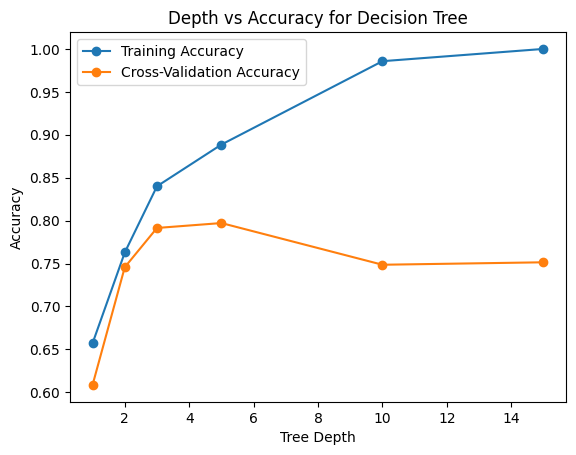

Best accuracy =  0.7971428571428572


In [288]:
from sklearn.model_selection import cross_val_score
depths = [1, 2, 3, 5, 10, None]
train_accs = []
cv_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    print("Training Accuracy depth ", d, ":", dt.score(X_train, y_train))
    # 5-fold CV
    cv_score = cross_val_score(dt, X_train, y_train, cv=5).mean()
    cv_accs.append(cv_score)
    print("CV Accuracy depth ", d, ":", cv_score)

# For plotting, convert 'None' to a numeric max depth representing unconstrained
plot_depths = [d if d is not None else 15 for d in depths]

plt.plot(plot_depths, train_accs, marker='o', label='Training Accuracy')
plt.plot(plot_depths, cv_accs, marker='o', label='Cross-Validation Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Depth vs Accuracy for Decision Tree')
plt.legend()
plt.show()

print("Best accuracy = ", max(cv_accs))

### Part 4: Support Vector Machines
In this part, the RBF Kernel Method performs far better than Linear SVM. The kernel SVM implicitly map the data into a higher-dimension feature space where the classes become linearly separable. This allows the model to form better decision boundary for the dataset. Linear SVM is kind of restricted so it cannot fully capture the pattern of the dataset.


Linear SVM accuracy: 0.575
Kernel SVM accuracy: 0.825


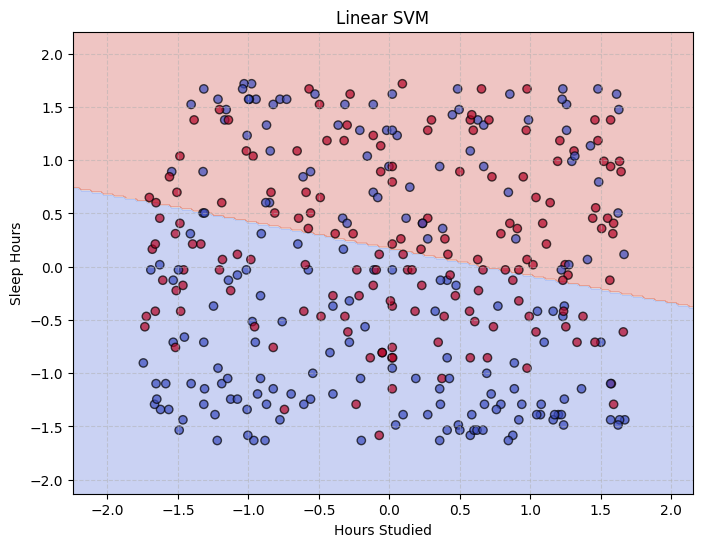

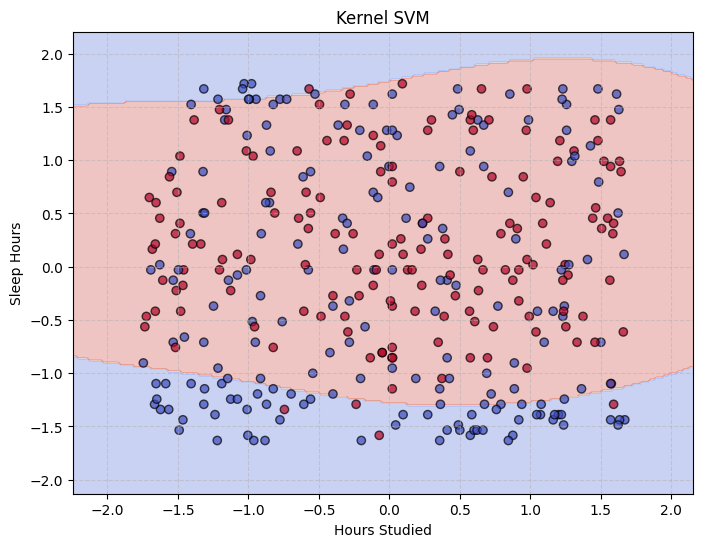

Polynomial SVM 2 accuracy: 0.8125
Polynomial SVM 3 accuracy: 0.5375
Polynomial SVM 5 accuracy: 0.5
Polynomial SVM 10 accuracy: 0.7125
Polynomial SVM 20 accuracy: 0.7125


In [289]:
#Part 4. Support Vector Machines
#Part 4.1
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn import svm

linear_svm = svm.SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
print("Linear SVM accuracy:", linear_svm.score(X_test, y_test))


kernel_svm = svm.SVC(kernel='rbf')
kernel_svm.fit(X_train, y_train)
print("Kernel SVM accuracy:", kernel_svm.score(X_test, y_test))

#Plotting the decision boundary
plot_decision_boundary(linear_svm, X_train, y_train, 'Linear SVM')
plot_decision_boundary(kernel_svm, X_train, y_train, 'Kernel SVM')

#Polynomial SVM with degree 2, 3, 5, 10, 20
degree = [2,3,5,10,20]
for d in degree:
    poly_svm = svm.SVC(kernel='poly', degree=d)
    poly_svm.fit(X_train, y_train)
    print("Polynomial SVM", d, "accuracy:", poly_svm.score(X_test, y_test))

### Part 4.2: Hyperparameter Tuning

The parameter C controls the penalty for misclassified datapoints. Very Small C encourages a wide smooth margin that aims a single decision boundary. Very large C heavily punishes misclassification (Hard-Margin SVM), leading to overfitting.



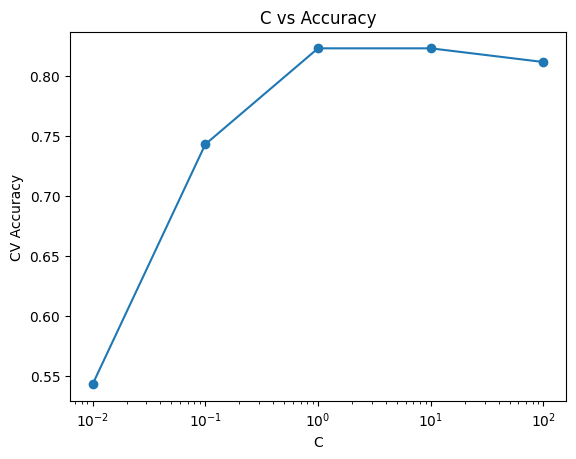

Best C: 1


In [290]:
#Part 4.2 Hyperparameter Tuning
C_values = [0.01, 0.1, 1, 10, 100]
cv_scores = []

for C in C_values:
    svc_model = svm.SVC(kernel='rbf', C=C)
    score = cross_val_score(svc_model, X_train, y_train, cv=5).mean()
    cv_scores.append(score)

plt.plot(C_values, cv_scores, marker='o')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("CV Accuracy")
plt.title("C vs Accuracy")
plt.show()

best_C = C_values[np.argmax(cv_scores)]
print("Best C:", best_C)

### Part 5: Random Forest
By utilizing bagging and random features during node splitting, RF minimizes the high variance that decision tree suffers from. Increasing the number of estimators does not cause overfitting. But if we do not limit the number of estimators, it will become computationally expensive without providing significant performance gains.


Random Forest Train accuracy: 1.0
OOB Accuracy:  0.8314285714285714
Random Forest Test Accuracy 0.7875


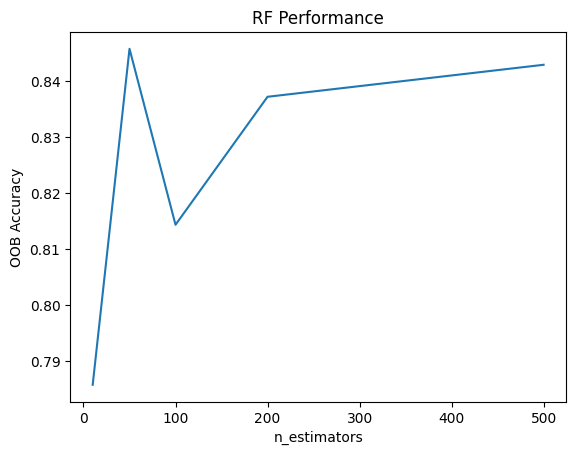

In [291]:
#Part 5: Random Forest Evaluation

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, oob_score=True)
rf.fit(X_train, y_train)
print("Random Forest Train accuracy:", rf.score(X_train, y_train))
print("OOB Accuracy: ", rf.oob_score_)
print("Random Forest Test Accuracy", rf.score(X_test, y_test))

trees = [10, 50, 100, 200, 500]
oob_scores = []

for n in trees:
    rf_temp = RandomForestClassifier(n_estimators=n, oob_score=True)
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.oob_score_)

plt.plot(trees, oob_scores)
plt.xlabel("n_estimators")
plt.ylabel("OOB Accuracy")
plt.title("RF Performance")
plt.show()

### Part 5.2: Feature Importance
To capture the nonlinear relationship, RF makes multiple splits to accumulate higher importance scores. The feature with the hihgest IG needed for the root split in a single decision tree will naturally by selected for early splits across RF. Limitations include data bias, heavy correlation between features that affects the overall results.




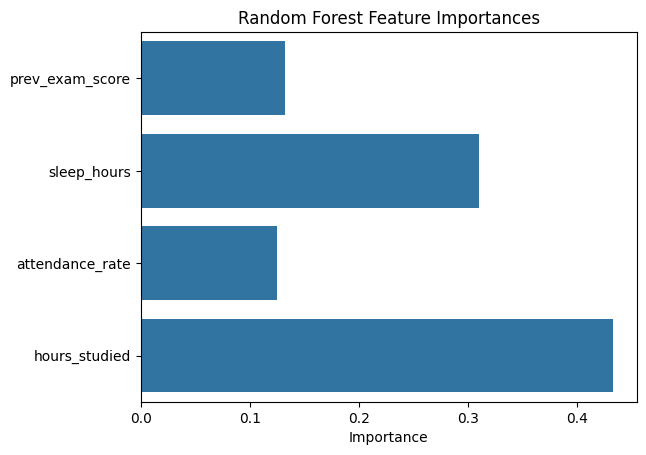

In [292]:
#Part 5.2 Feature Importances
importances = rf.feature_importances_
sns.barplot(x=importances, y=features)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.show()

###Part 6 Model Comparison and Final Evaluation (no separate points — incorporated into Summary)

In [293]:
#Part 6
#Best SVM - RBF Kernel SVM with C = 1
best_svm = svm.SVC(kernel='rbf', C=1)
best_svm.fit(X_train, y_train)
#Best Decision Tree (Depth = 3)
dt3 = DecisionTreeClassifier(max_depth=3)
dt3.fit(X_train, y_train)

data = {
    'Model': ['Logistic Regression', 'Decision Tree (best depth)', 'SVM (RBF + Best C)', 'Random Forest'],
    'Train Acc': [accuracy_score(y_train, train_preds), tree.score(X_train, y_train), best_svm.score(X_train, y_train), rf.score(X_train, y_train)],
    'CV/OOB Acc': [cross_val_score(lr, X_train, y_train, cv=5).mean(),
                   cross_val_score(tree, X_train, y_train, cv=5).mean(),
                   cross_val_score(best_svm, X_train, y_train, cv=5).mean(),
                   rf.oob_score_],
    'Test Acc': [accuracy_score(y_test, test_preds), tree.score(X_test, y_test), best_svm.score(X_test, y_test), rf.score(X_test, y_test)]
}

comp_df = pd.DataFrame(data)
display(comp_df.round(4))

,Model,Train Acc,CV/OOB Acc,Test Acc
0,Logistic Regression,0.5543,0.5543,0.5500
1,Decision Tree (best depth),0.8400,0.7914,0.8125
2,SVM (RBF + Best C),0.8800,0.8229,0.8250
3,Random Forest,1.0000,0.8314,0.7875


### Part 7: Summary
During this assignment we were tasked with comparing the accuracy of logistic regression, support vector machines(SVM), decision trees, and random forest models. Our logistic regression model produced a training accuracy and testing accuracy of 0.55 which is indicative of underfitting. When analyzing the scatterplots of hours_studied vs sleep_hours and prev_exam_score vs hours_studied, we can see that the data is not linearly separable due to overlapping classification points. Logistic regression and linear SVM perform poorly on this dataset since the data must be linearly separable in order for these classification models to perform well.

If we had more time, we would’ve liked to try different approaches to data cleaning such as removing rows with excessive feature values rather than imputing or imputing with the max or min values rather than the median. Some examples would include removing rows where hours_studied is negative or imputing excessive sleep hours with the max or min (replace negative sleep hours with 0 and sleep hours above 24 with 24).

Logistic regression has the high bias and low variance as there was minimal difference between the train and test accuracy (0.554 vs 0.550) indicating low variance but both values being far from ideal indicating high bias. Our Decision tree models with depth 1-2 showed the same indicators of low variance and high bias, our decision tree with depth 3 showed the best balance with low variance and low bias as it produced a training accuracy of 0.84 and CV accuracy of 0.79. Our decision tree with no depth limit indicated high variance and low bias as the training accuracy reached 1.0 but the CV accuracy dropped to 0.76. This indicates that the model memorized the noise and is not able to generalize well to unseen data. Our SVM model with RBF and C=1 achieved the smallest variance among all well performing models. The random forest model had low bias and high variance (train = 1.0, test = 0.7875) this indicates that bagging did not fully eliminate the variance as the majority of trees memorize the training data.

When conducting our hyperparameter tuning on C, we found that small values of C produced a wide margin that tolerates misclassifications, leading to high bias and low variance. Very large values of C cause the small hard-margin that penalizes every misclassification, leading to low bias and high variance. Our experiment found that C=1 as the point where the margin width and empirical risk are most balanced. Our experiments showed a significant increase in accuracy when going from linear SVM to the RBF SVM (0.575 to 0.825). The significant increase of the accuracy further explains that the dataset was not linearly seperable so that the linear SVM performed poorly. This validates the kernel trick as mapping data that is not linearly separable in the current dimensional space to a higher dimensional space becomes linearly separable. Our experiments on random forest showed that bagging reduces variance relative to individual trees, but does not eliminate it as the training accuracy was 1.0 but the test accuracy was 0.7875. Whereas, the OOB score was 0.831 shows that feature randomization at each split decorrelates the trees which reduces ensemble variance. When training a model, regardless of the type, we must consider the trade-off between accuracy vs complexity, training time vs interpretability and so on.

Logistic regression is the most interpretable model as the coefficients directly express the feature weights, but the low accuracy makes this model a bad choice. The trade-off here is maximum transparency for minimum usefulness on nonlinear data. The decision tree with depth 3 strikes the best accuracy to interpretability balance. Its test accuracy of 0.8125 is second highest and the training is very fast. RBF SVM got us the highest test accuracy of 0.825 but it is very hard to interpret which features matter most or what the decision rule will look like in the primary feature space. It also takes the longest to train for larger datasets. Random forest lands in the middle for interpretability as the feature importances provides some insight. It trains 100 trees which makes it slower than a single decision tree, but faster than SVM on a moderate-sized dataset.  


